In [222]:
%matplotlib widget
import mcstasscript as ms

trex = ms.McStas_instr(
    "TRex",
    author="Bing Li",
    origin="DMSC",
    output_path="trex_output",
)


# Instrument definition

In [223]:
L0 = trex.add_parameter(
    "L0",
    value=2.4,
    comment="wavelength in [Å] used to calculate the minimum and maximum wavelength "
    + "for the source component by adding and subtracting a set wavelength",
)

d_Li = trex.add_parameter(
    "d_Li",
    value=0.845,
    comment="wavelength band in [Å] to be simulated",
)


trex.add_parameter(
    "int",
    "mod_type",
    value=1,
    comment="this variable determines which moderator type is used "
    + "{0: Thermal moderator, 1: Bispectral moderator, 2: Cold moderator}",
)

bender = trex.add_parameter(
    "int", "bender", value=0, comment="bender out = 0, bender in = 1"
)
b_rot = trex.add_parameter(
    "b_rot", value=-0.5, comment="rotation of the cold neutron bender"
)

# Declare section

In [224]:
frac = trex.add_declare_var(
    "double",
    "frac",
    comment="Used in the Source component. Defines the statistical fraction of events"
    + "emitted from the cold part of the moderator, the value is determined later in the file"
    + " depending on the moderator type that was chosen",
)
lamb_1 = trex.add_declare_var("double", "lamb_1", comment="Wavelength min in [AA]")
lamb_2 = trex.add_declare_var("double", "lamb_2", comment="Wavelength max in [AA]")

# Initialize section

In [225]:
trex.append_initialize("""
// Source type
switch (mod_type)
	{
	case 0: {frac = 0.0; break;} // Thermal moderator
	case 1: {frac = 0.5; break;} // Bispectral moderator
	case 2: {frac = 1.0; break;} // Cold moderator
	}
// Source parameters
lamb_1 = L0-d_Li*1.1;
lamb_2 = L0+d_Li*1.1;
""")
trex.append_initialize('printf("lamb_1: %g \\n", lamb_1);')
trex.append_initialize('printf("lamb_2: %g \\n", lamb_2);')
# // Source parameters
# 	vi = 2*PI*K2V/Li;
# 	v1 = 2*PI*K2V/lamb_1;   // slowest neutron
# 	v2 = 2*PI*K2V/lamb_2;   // fastest neutron

# Trace section

In [226]:
# https://mcstas.org/download/components/3.7.9/sources/ESS_butterfly.html
source = trex.add_component(name="source", component_name="ESS_butterfly")
source.set_parameters(
    sector='"W"',
    beamline=7,
    yheight=0.03,  # [m], moderator height, 0.03 to 0.06
    cold_frac=frac,
    # target_index not needed if using dist
    dist=2,  # [m], distance to focusing rectange
    focus_xw=0.095,  # [m], size of focusing rectange
    focus_yh=0.035,
    # c_performance: float = 1.0
    # t_performance: float = 1.0
    Lmin=lamb_1,  # in Angstrom
    Lmax=lamb_2,  # in Angstrom
    n_pulses=1,
    acc_power=2,
    # tfocus_dist = 32  # [m], Position of time focusing window along z axis
    # tfocus_time = tof_BW1  # [s], position of time focusing window`
    # tfocus_width = 0.01218  # [s], width of time focusing window`
)

In [227]:
source_monitor_xy = trex.add_component(
    "source_monitor_xy", "Monitor_nD", AT=[-0.002, 0, 1.8953]
)
source_monitor_xy.set_parameters(
    xwidth=0.1, yheight=0.04, restore_neutron=1, filename='"source_monitor_xy.dat"'
)
source_monitor_xy.options = (
    '"x limits [-0.06:0.06] bins = 100, y limits [-0.03:0.03] bins = 100"'
)
source_monitor_xy.set_comment(
    "Note: -0.002 because guide is asymmetric here (47mm-43mm)/2"
)


In [228]:
source_monitor_div = trex.add_component(
    "source_monitor_div", "Monitor_nD", AT=[-0.002, 0, 1.8954]
)
source_monitor_div.set_parameters(
    xwidth=0.09, yheight=0.03, restore_neutron=1, filename='"source_monitor_div.dat"'
)
source_monitor_div.options = (
    '"hdiv limits [-4.5:4.5] bins = 100, vdiv limits [-2.5:2.5] bins = 100"'
)

In [229]:
source_monitor_lam = trex.add_component(
    "source_monitor_lam", "Monitor_nD", AT=[-0.002, 0, 1.8955]
)
source_monitor_lam.set_parameters(
    xwidth=0.09, yheight=0.03, restore_neutron=1, filename='"source_monitor_lam.dat"'
)
source_monitor_lam.options = '"lambda limits [0.5:7.0] bins = 130"'

In [230]:
for i in range(9):
    if i in (2, 6):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry=f'"./OFF_files/try{i}.off"')

trex.get_component("guide_0").set_comment("NBOA section")

In [231]:
guide = trex.add_component("guide_10", "Guide_anyshape_r", WHEN="bender==0")
guide.set_parameters(geometry='"./OFF_files/try10.off"')
guide.set_comment("BBGOA: thermal -> guide 10 & 11; cold: bender & guide 11")

In [232]:
# https://mcstas.org/download/components/3.7.9/optics/Pol_bender.html
bender = trex.add_component("bender", "Pol_bender", WHEN="bender==1")
bender.set_AT([-0.017, 0, 5.399])
bender.set_ROTATED([0 + 0.00192, b_rot, 0])
bender.set_parameters(
    xwidth=0.06384,  # [m], with at entrance
    yheight=0.046,  # [m], height at entrance
    length=0.05,  # [m], length along center
    radius=7.2,  # [m], radius of curvature +/- is left/right
    nslit=425,  # num of slits
    d=1e-6,  # [m], width of spacers
    endFlat=0,  # entrance/exit planes NOT parallel
    drawOption=2,  #
    # Top mirror Parameters for spin up/down standard reflectivity function
    # StdReflecFunc = {R0, Qc, alpha, m, W}
    # Bot -> Top, Left -> Top, Right -> Left
    rTopUpPar={0.99, 0.0219, 3.02, 4.0, 0.003},
    rTopDownPar={0.99, 0.0219, 3.02, 4.0, 0.003},
)

bender.set_comment(
    "bender: 63.84mm x 46mm x 50mm (WxHxL), 0.15mm Si channels/ NiTi m=4 curve=7.2m"
)

In [233]:
guide = trex.add_component("guide_11", "Guide_anyshape_r")
guide.set_parameters(geometry='"./OFF_files/try11.off"')

In [234]:
# https://mcstas.org/download/components/3.7.9/optics/Slit.html
slit = trex.add_component("slit", "Slit", AT=[-0.017, 0, 5.915])
slit.set_parameters(
    xwidth=0.06,  # [m]
    yheight=0.046,  # [m]
)

In [235]:
insert_monitor_xy = trex.add_component(
    "insert_monitor_xy", "Monitor_nD", AT=[-0.017, 0.0, 5.9151]
)
insert_monitor_xy.set_parameters(
    xwidth=0.06, yheight=0.046, restore_neutron=1, filename='"insert_monitor_xy.dat"'
)
insert_monitor_xy.options = (
    #'"x limits [-0.03:0.03] bins = 100, y limits [-0.023:0.023] bins = 100"'
    '"x limits [-0.04:0.04] bins = 100, y limits [-0.033:0.033] bins = 100"'
)

In [236]:
insert_monitor_div = trex.add_component(
    "insert_monitor_div", "Monitor_nD", AT=[-0.017, 0, 5.9152]
)
insert_monitor_div.set_parameters(
    xwidth=0.06, yheight=0.046, restore_neutron=1, filename='"insert_monitor_div.dat"'
)
insert_monitor_div.options = (
    '"hdiv limits [-2.0:2.0] bins = 201, vdiv limits [-1.0:1.0] bins = 201"'
)

In [237]:
insert_monitor_lam = trex.add_component(
    "insert_monitor_lam", "Monitor_nD", AT=[-0.017, 0, 5.9153]
)
insert_monitor_lam.set_parameters(
    xwidth=0.06, yheight=0.046, restore_neutron=1, filename='"insert_monitor_lam.dat"'
)
insert_monitor_lam.options = '"lambda limits [0.5:7.0] bins = 130"'

In [238]:
inset_monitor_ToF = trex.add_component(
    "inset_monitor_ToF", "Monitor_nD", AT=[-0.017, 0, 5.9154]
)
inset_monitor_ToF.set_parameters(
    xwidth=0.07, yheight=0.07, restore_neutron=1, filename='"inset_monitor_ToF.dat"'
)
inset_monitor_ToF.options = '"t limits [0.0:0.020] bins = 20000"'

In [239]:
for i in range(13, 48):
    if i in (17, 21, 26, 31, 35, 38, 43):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry=f'"./OFF_files/try{i}.off"')

trex.get_component("guide_13").set_comment("In-bunker section plus a little bit")
trex.get_component("guide_39").set_comment("Bunker wall insert starts here")

In [240]:
BW_Chopper_1 = trex.add_component(
    "BW_Chopper_1",
    "MultiDiskChopper",
    AT=[0.011348994153930106, 0.0, 32.0],
    ROTATED=[0, 0.124542024141650, 0],
    comment="Bandwidth chopper 1 ",
)

In [241]:
trex.component_help("MultiDiskChopper")

 ___ Help MultiDiskChopper __________________________________________________________
|optional parameter|required parameter|default value|user specified value|
slit_center = "0180" [string] // (deg)   Angular position of the slits (similar 
                                 to slit_width) 
slit_width = "1020" [string] // (deg)   Angular width of the slits, given as 
                                list in a string separated by space ' ', comma ',', 
                                underscore '_' or semicolon ';'. Example 
nslits = 2.0 [] // Number of slits to read from slit_width and slit_center
delta_y = -0.3 [m] // y-position of the chopper rotation axis. If the chopper 
                      is located above the guide (delta_y>0), the coordinate system 
                      will be mirrored such that the created pulse pattern in time 
                      is the same as for delta_y<0. A warning will be printed in 
                      this case. 
nu = 0.0 [Hz] // Rotation speed o

In [242]:
# /* Bandwidth chopper 1 */

# COMPONENT BW_Chopper_1 = MultiDiskChopper(
#     slit_center = theta_pos_BW1,
#     slit_width = theta_width_BW1,
#     radius = radius_BW1,
#     delta_y = delta_y_BW1,
#     nu=f_BW1,
#     delay = delay_BW1,
#     nslits = nslits_BW1)
# AT (0.011348994153930106, 0.0, 32.0) RELATIVE ABSOLUTE
# ROTATED (0, 0.124542024141650,0) RELATIVE ABSOLUTE

# Check and Run

In [243]:
try:
    trex.check_for_errors()
except Exception as e:
    print(str(e))

In [244]:
trex.settings(ncount=1e7, output_path="trex_output", mpi="auto")
data = trex.backengine()
print(data)


INFO: Using directory: "/Users/bingli/Documents/GitHub/mdnorm/instrument/trex_output"
INFO: Regenerating c-file: TRex.c
Info:    'Guide_anyshape_r' is a contributed component.
Info:    'MultiDiskChopper' is a contributed component.
CFLAGS=  -DUSE_OFF 
              
 The parameter rTopUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rTopDownPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotDownPar o

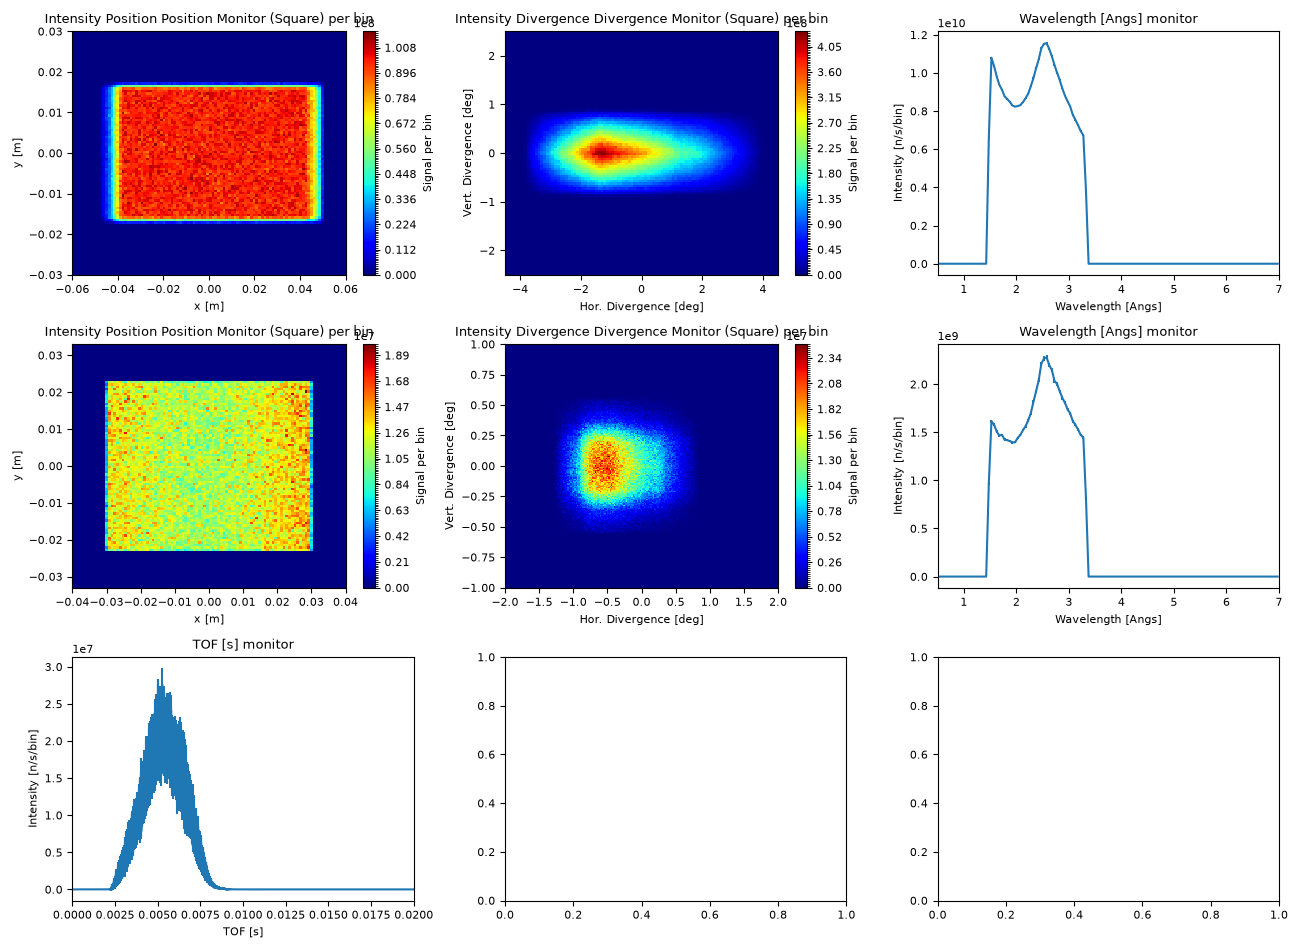

In [245]:
ms.make_sub_plot(data, fontsize=8)

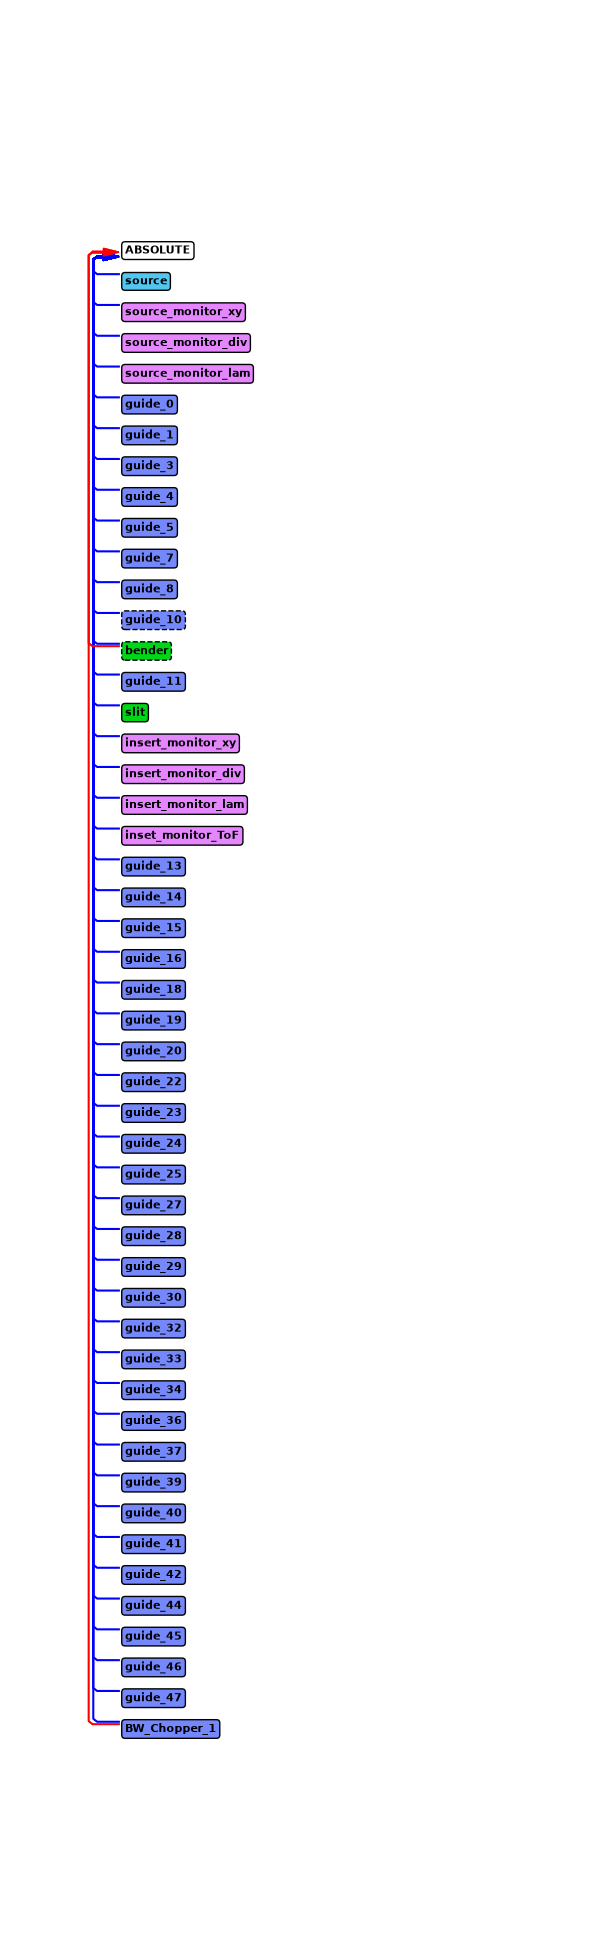

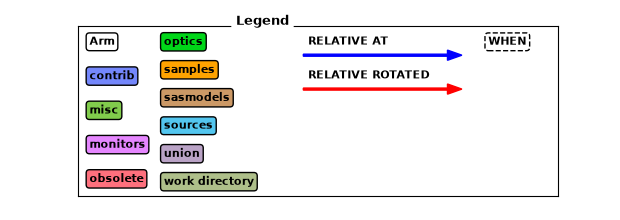

In [246]:
trex.show_diagram()

In [247]:
# trex.show_instrument(backend="pythreejs")